In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [25]:
df = pd.read_csv("data/cleaned_imdb.csv")
print(df.shape)
print(df.columns)
df.head()

(50000, 3)
Index(['review', 'sentiment', 'clean_review'], dtype='str')


,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,1,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,1,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,0,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter matteis love time money visually stunni...


In [ ]:
#drop empty rosw
df = df[["clean_review", "sentiment"]].dropna()

#ensure sentiment is 0 or 1 int
df["sentiment"] = pd.to_numeric(df["sentiment"], errors="coerce")
df = df[df["sentiment"].isin([0, 1])]
df["sentiment"] = df["sentiment"].astype(int)

#checking
print(df.shape)
print(df["sentiment"].value_counts())

(50000, 2)
sentiment
1    25000
0    25000
Name: count, dtype: int64


In [ ]:
#building feature matrix X and y
X = df["clean_review"].astype(str)
y = df["sentiment"]

#debug
print("Example review:\n", X.iloc[0][:200])

Example review:
 one reviewers mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scenes violence set right word go trust not show faint hearted timid s


### Splitting

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", len(X_train), "Test:", len(X_test))

Train: 40000 Test: 10000


### TF-IDF Vectorizer

In [ ]:
#unigrams and bigrams are used to capture indiv words and short phrases
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print(X_train_vec.shape, X_test_vec.shape)

(40000, 10000) (10000, 10000)


TF-IDF was used to convert the movie reviews into numerical features. This allows the classidier to learn from the improtance of words and short phrases.

### Building the KNN Model

In [30]:
knn = KNeighborsClassifier(
    n_neighbors=7,
    metric="cosine",
    weights="distance"
)

knn.fit(X_train_vec, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Evaluating

In [40]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

y_pred = knn.predict(X_test_vec)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy:  0.7623
              precision    recall  f1-score   support

           0       0.80      0.69      0.75      5000
           1       0.73      0.83      0.78      5000

    accuracy                           0.76     10000
   macro avg       0.77      0.76      0.76     10000
weighted avg       0.77      0.76      0.76     10000

Confusion matrix:
 [[3474 1526]
 [ 851 4149]]


Confusion matrix(y_test, y_pred) [[3474 1526]
 [ 851 4149]]


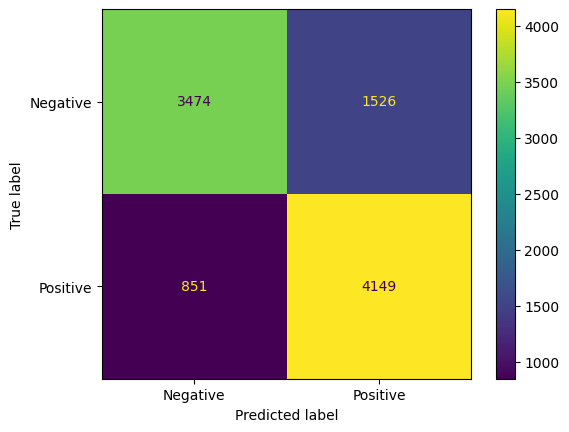

In [41]:
print("Confusion matrix(y_test, y_pred)", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(values_format="d")
plt.show()

### Tuning the K

In [42]:
for k in [3,5,7,9,11]:
    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine", weights="distance")
    knn.fit(X_train_vec, y_train)
    y_pred = knn.predict(X_test_vec)
    print(f"K={k}, Accuracy={accuracy_score(y_test, y_pred): .4f}")

K=3, Accuracy= 0.7391
K=5, Accuracy= 0.7523
K=7, Accuracy= 0.7623
K=9, Accuracy= 0.7668
K=11, Accuracy= 0.7718


Multiple values of K were evaluated for the KNN classifier and among the tested values, K = 11 achieved the highest accurac of 0.7718 on the test set. Hence, K is the optimal parameter for this model.